# Python Analysis for Telecome Customer Support Ticket

## Task 1:- Importing libraries and Data Loading

In [127]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [128]:
data= pd.read_csv("Telecom_Customer_Support_Tickets_Gigantic_Dataset - Telecom_Customer_Support_Tickets_Gigantic_Dataset.csv")

In [129]:
data.shape

(62500, 9)

In [134]:
data.head()

,Ticket_ID,Created_Date,Region,City,Issue_Category,Priority,Resolution_Time_Hours,Customer_Type,Satisfaction_Score
0,500000,2022-07-27,NaN,Pune,Billing,Medium,36.0,Existing,5.0
1,500001,2024-04-04,NaN,Chennai,NaN,Medium,10.0,Existing,2.0
2,500002,2024-02-12,Central,Ahmedabad,Network,High,41.0,New,2.0
3,500003,2022-02-18,Central,Bengaluru,Service,Low,206.0,New,4.0
4,500004,2023-01-04,Central,Chennai,Hardware,Critical,31.0,Existing,5.0


In [130]:
data

,Ticket_ID,Created_Date,Region,City,Issue_Category,Priority,Resolution_Time_Hours,Customer_Type,Satisfaction_Score
0,500000,2022-07-27,NaN,Pune,Billing,Medium,36.0,Existing,5.0
1,500001,2024-04-04,NaN,Chennai,NaN,Medium,10.0,Existing,2.0
2,500002,2024-02-12,Central,Ahmedabad,Network,High,41.0,New,2.0
3,500003,2022-02-18,Central,Bengaluru,Service,Low,206.0,New,4.0
4,500004,2023-01-04,Central,Chennai,Hardware,Critical,31.0,Existing,5.0
...,...,...,...,...,...,...,...,...,...
62495,501126,2023-01-02,West,Hyderabad,Service,Low,218.0,Existing,4.0
62496,506196,2024-01-11,West,NaN,Hardware,Medium,10.0,NaN,NaN
62497,516269,2022-06-11,Central,Kolkata,Billing,Low,92.0,New,1.0
62498,542189,2022-05-25,South,Pune,NaN,Low,100.0,New,3.0


## Task:-2 Data Cleaning & EDA

### Indentifying and Handeling missing values

In [6]:
data.isnull().sum()

Ticket_ID                    0
Created_Date                 0
Region                   12543
City                      6921
Issue_Category            6310
Priority                     0
Resolution_Time_Hours      278
Customer_Type             6126
Satisfaction_Score        6231
dtype: int64

In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62500 entries, 0 to 62499
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Ticket_ID              62500 non-null  int64  
 1   Created_Date           62500 non-null  object 
 2   Region                 49957 non-null  object 
 3   City                   55579 non-null  object 
 4   Issue_Category         56190 non-null  object 
 5   Priority               62500 non-null  object 
 6   Resolution_Time_Hours  62222 non-null  float64
 7   Customer_Type          56374 non-null  object 
 8   Satisfaction_Score     56269 non-null  float64
dtypes: float64(2), int64(1), object(6)
memory usage: 4.3+ MB


In [113]:
clean_data=data

clean_data[["Region"]].fillna("NotDefined")
clean_data[["City"]].fillna("Unknown")
clean_data[["Issue_Category"]].fillna("Undefined")
clean_data[["Resolution_Time_Hours"]].fillna(data[["Resolution_Time_Hours"]].mean())
clean_data[["Customer_Type"]].fillna("Unknown")
clean_data[["Satisfaction_Score"]].fillna(data[["Satisfaction_Score"]].mean())
clean_data

,Ticket_ID,Created_Date,Region,City,Issue_Category,Priority,Resolution_Time_Hours,Customer_Type,Satisfaction_Score
0,500000,2022-07-27,NaN,Pune,Billing,Medium,36.0,Existing,5.0
1,500001,2024-04-04,NaN,Chennai,NaN,Medium,10.0,Existing,2.0
2,500002,2024-02-12,Central,Ahmedabad,Network,High,41.0,New,2.0
3,500003,2022-02-18,Central,Bengaluru,Service,Low,206.0,New,4.0
4,500004,2023-01-04,Central,Chennai,Hardware,Critical,31.0,Existing,5.0
...,...,...,...,...,...,...,...,...,...
62495,501126,2023-01-02,West,Hyderabad,Service,Low,218.0,Existing,4.0
62496,506196,2024-01-11,West,NaN,Hardware,Medium,10.0,NaN,NaN
62497,516269,2022-06-11,Central,Kolkata,Billing,Low,92.0,New,1.0
62498,542189,2022-05-25,South,Pune,NaN,Low,100.0,New,3.0


In [114]:
clean_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62500 entries, 0 to 62499
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Ticket_ID              62500 non-null  int64  
 1   Created_Date           62500 non-null  object 
 2   Region                 49957 non-null  object 
 3   City                   55579 non-null  object 
 4   Issue_Category         56190 non-null  object 
 5   Priority               62500 non-null  object 
 6   Resolution_Time_Hours  62222 non-null  float64
 7   Customer_Type          56374 non-null  object 
 8   Satisfaction_Score     56269 non-null  float64
dtypes: float64(2), int64(1), object(6)
memory usage: 4.3+ MB


In [117]:
clean_data.dtypes

Ticket_ID                  int64
Created_Date              object
Region                    object
City                      object
Issue_Category            object
Priority                  object
Resolution_Time_Hours    float64
Customer_Type             object
Satisfaction_Score       float64
dtype: object

In [28]:
data.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
62495     True
62496     True
62497     True
62498     True
62499     True
Length: 62500, dtype: bool

In [29]:
data.describe()

,Ticket_ID,Resolution_Time_Hours,Satisfaction_Score
count,62500.000000,62222.000000,56269.000000
mean,530003.994160,119.250201,3.220548
std,17317.636308,68.837770,1.226304
min,500000.000000,1.000000,1.000000
25%,515004.750000,60.000000,2.000000
50%,530018.500000,119.000000,3.000000
75%,544988.000000,179.000000,4.000000
max,559999.000000,239.000000,5.000000


## Task3:- Bussiness/ Operational Data Analysis

In [30]:
data

,Ticket_ID,Created_Date,Region,City,Issue_Category,Priority,Resolution_Time_Hours,Customer_Type,Satisfaction_Score
0,500000,2022-07-27,NaN,Pune,Billing,Medium,36.0,Existing,5.0
1,500001,2024-04-04,NaN,Chennai,NaN,Medium,10.0,Existing,2.0
2,500002,2024-02-12,Central,Ahmedabad,Network,High,41.0,New,2.0
3,500003,2022-02-18,Central,Bengaluru,Service,Low,206.0,New,4.0
4,500004,2023-01-04,Central,Chennai,Hardware,Critical,31.0,Existing,5.0
...,...,...,...,...,...,...,...,...,...
62495,501126,2023-01-02,West,Hyderabad,Service,Low,218.0,Existing,4.0
62496,506196,2024-01-11,West,NaN,Hardware,Medium,10.0,NaN,NaN
62497,516269,2022-06-11,Central,Kolkata,Billing,Low,92.0,New,1.0
62498,542189,2022-05-25,South,Pune,NaN,Low,100.0,New,3.0


In [36]:
data[["Issue_Category"]].value_counts()

Issue_Category
Billing           11344
Network           11311
Software          11278
Service           11178
Hardware          11079
Name: count, dtype: int64

In [86]:
data[["Priority","Resolution_Time_Hours"]].value_counts()

Priority                 62500
Resolution_Time_Hours    62222
dtype: int64

In [83]:
data[["Region","Satisfaction_Score"]].value_count()

Region   Satisfaction_Score
East     4.0                   2573
South    4.0                   2552
North    4.0                   2518
East     3.0                   2512
West     4.0                   2508
South    3.0                   2497
Central  4.0                   2486
West     3.0                   2481
North    3.0                   2443
Central  3.0                   2412
         2.0                   1610
East     2.0                   1562
West     2.0                   1524
East     5.0                   1518
North    2.0                   1517
Central  5.0                   1513
South    2.0                   1511
North    5.0                   1499
South    5.0                   1455
West     5.0                   1444
Central  1.0                   1013
North    1.0                    993
South    1.0                    986
East     1.0                    946
West     1.0                    936
Name: count, dtype: int64

In [84]:
data[["Resolution_Time_Hours"]].value_counts()

Resolution_Time_Hours
103.0                    303
108.0                    301
40.0                     295
24.0                     291
174.0                    291
                        ... 
199.0                    229
168.0                    228
36.0                     228
232.0                    226
18.0                     219
Name: count, Length: 239, dtype: int64

## Task4:- Data Visualizations

In [87]:
data

,Ticket_ID,Created_Date,Region,City,Issue_Category,Priority,Resolution_Time_Hours,Customer_Type,Satisfaction_Score
0,500000,2022-07-27,NaN,Pune,Billing,Medium,36.0,Existing,5.0
1,500001,2024-04-04,NaN,Chennai,NaN,Medium,10.0,Existing,2.0
2,500002,2024-02-12,Central,Ahmedabad,Network,High,41.0,New,2.0
3,500003,2022-02-18,Central,Bengaluru,Service,Low,206.0,New,4.0
4,500004,2023-01-04,Central,Chennai,Hardware,Critical,31.0,Existing,5.0
...,...,...,...,...,...,...,...,...,...
62495,501126,2023-01-02,West,Hyderabad,Service,Low,218.0,Existing,4.0
62496,506196,2024-01-11,West,NaN,Hardware,Medium,10.0,NaN,NaN
62497,516269,2022-06-11,Central,Kolkata,Billing,Low,92.0,New,1.0
62498,542189,2022-05-25,South,Pune,NaN,Low,100.0,New,3.0


### Line Chart

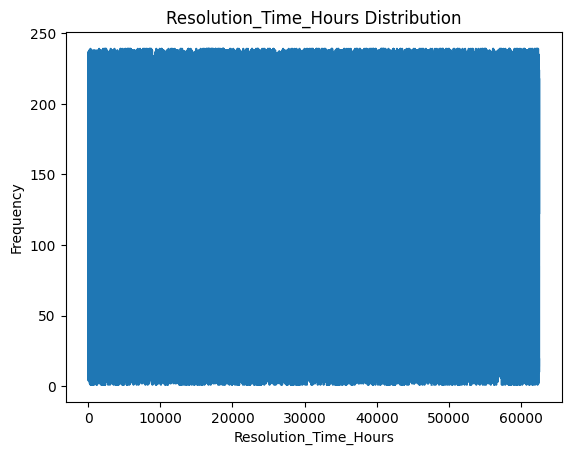

In [123]:
plt.plot(data[["Resolution_Time_Hours"]])
plt.title("Resolution_Time_Hours Distribution")
plt.xlabel("Resolution_Time_Hours")
plt.ylabel("Frequency")
plt.show()